# Статистика, DS-поток
## Марафон-домашка SM.9, практическая часть

**Правила:**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания будут сдавать устный зачет.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, **не исправляйте и не удаляйте условия!** Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.



**Правила оформления теоретических задач:**

* Решения необходимо прислать в виде $\LaTeX$ в markdown-ячейках.
* В решениях поясняйте, чем вы пользуетесь, хотя бы кратко. Например, если пользуетесь независимостью, то достаточно подписи вида "*X и Y незав.*"
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.

**Баллы за задание.**

* Задача 1 &mdash; 10 баллов;
* Задача 2 &mdash; 150 баллов;
* Задача 3 &mdash; 130 баллов;





In [ ]:
# Bot check

# HW_ID: ds_sm9
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [61]:
import numpy as np
import pandas as pd
import scipy.stats as sps
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid', font_scale=1.3, palette='Set2')

---
### Задача 3.

Рассмотрим два признака $x_1, x_2$ и таргет $y$. Будем предполагать зависимость $y(x) = \theta_0 + \theta_1 x_1 + \theta_2 x_2$. Для проверки гипотезы о *не*значимости признака $x_2$, то есть $\mathsf{H}_0\colon \theta_2=0$, на практике широко используется $T$-критерий (например, в AB-тестировании), который мы получили в предположениях гауссовской линейной модели. Проведем его исследования.

**1.** Оцените вероятность ошибки I рода в предположениях гауссовской линейной модели, в частности, **при наличии гомоскедастичности**. Для этого повторите достаточное количество раз (не менее $10^4$) следующую процедуру и усредните результаты. Подобную процедуру мы уже выполняли в предыдущих заданиях, включая построение доверительного интервала.
> 1. Сгенерируйте некоторым образом выборку размера $n=200$ из признаков $x_1$ и $x_2$.
> 2. Сгенерируйте целевую метку в предположениях гауссовской линейной модели. В процедуре оценки вероятности ошибки I рода на данном этапе необходимо брать $\theta_2 = 0$, то есть генерировать данные при справедливости $\mathsf{H}_0$.
> 3. Примените критерий.
> 4. Проведя достаточное количество шагов 1-3, сделайте оценку вероятности ошибки I рода и постройте соответствующий доверительный интервал.
> 
> *Важно:* распределение данных и шума должно быть одинаковым в каждом эксперименте!


*Совет.* Используйте `tqdm` в циклах. Производите отладку кода на малом количестве итераций.

In [54]:
m = 10_000
n = 200
d = 3
loc = 0
scale = 2


is_reject = []
alpha = 0.05
T = sps.t(n - d).ppf(1 - alpha / 2)

t0, t1, t2 = 5, 1, 0
t = np.array([t0, t1, t2])

for i in tqdm(range(m)):
    x = sps.uniform(loc=0, scale=10).rvs(size=(n, d - 1))
    #Добавим столбец единиц для учёта сдвига
    x = np.concatenate([np.ones(n).reshape(-1, 1), x], axis=1)
    
    noise = sps.norm(loc=loc, scale=scale).rvs(size=n)
    y = x @ t + noise
    t_hat = np.linalg.pinv(x) @ y
    scale_hat = np.sqrt(1 / (n - d) * np.linalg.norm((y - x @ t_hat)) ** 2)
    
    is_reject.append(np.abs(t_hat[2]) > T * scale_hat * np.sqrt(np.linalg.inv(x.T @ x)[2, 2]))

  0%|          | 0/10000 [00:00<?, ?it/s]

In [57]:
#Используем асимптотический доверительный интервал Вальда
z = sps.norm.ppf(1 - alpha / 2)
p_hat = np.mean(is_reject)
scale_hat = np.sqrt((p_hat)*(1 - p_hat))
left = p_hat - z * scale_hat / np.sqrt(m)
right = p_hat + z * scale_hat / np.sqrt(m)
print(f'Оценка: {p_hat}')
print(f'Доверительный интервал: ({left:.3f}, {right:.3f})')

Оценка: 0.054
Доверительный интервал: (0.050, 0.058)


Результаты могут сильно зависеть от того, как были сгенерированы данные для эксперимента. Для надежности повторите эксперимент, как-либо иначе сгенерировав признаки. Например, для генерации можно взять другое распределение признаков с конечной дисперсией.

In [59]:
m = 10_000
n = 200
d = 3
loc = 0
scale = 2


is_reject = []
alpha = 0.05
T = sps.t(n - d).ppf(1 - alpha / 2)

t0, t1, t2 = 5, 1, 0
t = np.array([t0, t1, t2])

for i in tqdm(range(m)):
    x = sps.gamma(a=3, scale=0.5).rvs(size=(n, d - 1))
    x = np.concatenate([ np.ones(n).reshape(-1, 1), x], axis=1)
    
    noise = sps.norm(loc=loc, scale=scale).rvs(size=n)
    y = x @ t + noise
    t_hat = np.linalg.pinv(x) @ y
    scale_hat = np.sqrt(1 / (n - d) * np.linalg.norm((y - x @ t_hat)) ** 2)
    
    is_reject.append(np.abs(t_hat[2]) > T * scale_hat * np.sqrt(np.linalg.inv(x.T @ x)[2, 2]))

  0%|          | 0/10000 [00:00<?, ?it/s]

In [62]:
z = sps.norm.ppf(1 - alpha / 2)
p_hat = np.mean(is_reject)
scale_hat = np.sqrt((p_hat)*(1 - p_hat))
left = p_hat - z * scale_hat / np.sqrt(m)
right = p_hat + z * scale_hat / np.sqrt(m)
print(f'Оценка: {p_hat}')
print(f'Доверительный интервал: ({left:.3f}, {right:.3f})')

Оценка: 0.0529
Доверительный интервал: (0.049, 0.057)


**2.** Повторите проведенные эксперименты **для случая гетероскедастичности**. Для этого сгенерируйте $\varepsilon_i$ из нормального распределения с дисперсией, зависящей от признаков. Например, в случае неотрицательных признаков можно взять $\sqrt{\mathsf{D} \varepsilon_i} = \psi_0 + \psi_1 x_{i1} + \psi_2 x_{i2}$ для некоторых коэффициентов $\psi_j$.

В частности, исследуйте случаи
* $\psi_1\not=0, \psi_2=0$;
* $\psi_1=0, \psi_2\not=0$;
* $\psi_1\not=0, \psi_2\not=0$;


*Примечания.*
* Первые две ситуации разные, поскольку мы проводим исследование критериев проверки гипотезы о незначимости признака $x_2$.
* В данном случае мы применяем критерий при неверных предположениях модели, тем самым хотим исследовать поведение критерия при отклонениях от этих предположений.

In [67]:
def hetero(p0, p1, p2):
    m = 10_000
    n = 200
    d = 3
    loc = 0
    
    
    is_reject = []
    alpha = 0.05
    T = sps.t(n - d).ppf(1 - alpha / 2)
    
    t0, t1, t2 = 5, 1, 0
    t = np.array([t0, t1, t2])
    
    p0, p1, p2 = p0, p1, p2
    
    for i in tqdm(range(m)):
        x = sps.gamma(a=3, scale=0.5).rvs(size=(n, d - 1))
        x = np.concatenate([np.ones(n).reshape(-1, 1), x], axis=1)
        
        scale = p0 + p1 * x[:, 1] + p2 * x[:, 2]
        noise = sps.norm(loc=loc, scale=scale).rvs(size=n)
        y = x @ t + noise
        t_hat = np.linalg.pinv(x) @ y
        scale_hat = np.sqrt(1 / (n - d) * np.linalg.norm((y - x @ t_hat)) ** 2)
        is_reject.append(np.abs(t_hat[2]) > T * scale_hat * np.sqrt(np.linalg.inv(x.T @ x)[2, 2]))

    z = sps.norm.ppf(1 - alpha / 2)
    p_hat = np.mean(is_reject)
    scale_hat = np.sqrt((p_hat)*(1 - p_hat))
    left = p_hat - z * scale_hat / np.sqrt(m)
    right = p_hat + z * scale_hat / np.sqrt(m)
    print(f'Оценка: {p_hat}')
    print(f'Доверительный интервал: ({left:.3f}, {right:.3f})')

In [68]:
#1
hetero(2, 3, 0)

  0%|          | 0/10000 [00:00<?, ?it/s]

Оценка: 0.0515
Доверительный интервал: (0.047, 0.056)


In [69]:
hetero(100, 200, 0)

  0%|          | 0/10000 [00:00<?, ?it/s]

Оценка: 0.0513
Доверительный интервал: (0.047, 0.056)


In [70]:
#2
hetero(2, 0, 3)

  0%|          | 0/10000 [00:00<?, ?it/s]

Оценка: 0.1879
Доверительный интервал: (0.180, 0.196)


In [72]:
hetero(100, 0, 200)

  0%|          | 0/10000 [00:00<?, ?it/s]

Оценка: 0.2097
Доверительный интервал: (0.202, 0.218)


In [71]:
#3
hetero(2, 3, 4)

  0%|          | 0/10000 [00:00<?, ?it/s]

Оценка: 0.1427
Доверительный интервал: (0.136, 0.150)


In [73]:
hetero(200, 300, 400)

  0%|          | 0/10000 [00:00<?, ?it/s]

Оценка: 0.1397
Доверительный интервал: (0.133, 0.146)


Видим, что если дисперсия не зависит от исселудемого на незначимость признака, то гомоскедастичная оценка хорошо работает даже при гетероскедастичном шуме. Однако если зависимость есть, то Y сильно больше зависит от исследуемого признака, однако это не учитывается, поэтому ошибка первого рода увеличивается

**3.** Исследуйте, как меняется вероятность ошибки I рода при отклонении распределения шума от нормальности. Шум должен быть **гомоскедастичным**, дисперсия конечна.

In [76]:
sps.t(1).args[0]

1

In [79]:
def noises(gen):
    m = 10_000
    n = 200
    d = 3
    
    is_reject = []
    alpha = 0.05
    T = sps.t(n - d).ppf(1 - alpha / 2)
    
    t0, t1, t2 = 5, 1, 0
    t = np.array([t0, t1, t2])
    
    for i in tqdm(range(m)):
        x = sps.gamma(a=3, scale=0.5).rvs(size=(n, d - 1))
        x = np.concatenate([np.ones(n).reshape(-1, 1), x], axis=1)
        
        noise = gen.rvs(size=n)
        y = x @ t + noise
        t_hat = np.linalg.pinv(x) @ y
        scale_hat = np.sqrt(1 / (n - d) * np.linalg.norm((y - x @ t_hat)) ** 2)
        is_reject.append(np.abs(t_hat[2]) > T * scale_hat * np.sqrt(np.linalg.inv(x.T @ x)[2, 2]))

    z = sps.norm.ppf(1 - alpha / 2)
    p_hat = np.mean(is_reject)
    scale_hat = np.sqrt((p_hat)*(1 - p_hat))
    left = p_hat - z * scale_hat / np.sqrt(m)
    right = p_hat + z * scale_hat / np.sqrt(m)
    print(f'Оценка: {p_hat}')
    print(f'Доверительный интервал: ({left:.3f}, {right:.3f})')
#При гамма шуме
noises(sps.gamma(3, 0.5))

  0%|          | 0/10000 [00:00<?, ?it/s]

Оценка: 0.0508
Доверительный интервал: (0.046, 0.055)


In [80]:
#При экспоненциальном шуме
noises(sps.gamma(1, 1))

  0%|          | 0/10000 [00:00<?, ?it/s]

Оценка: 0.0532
Доверительный интервал: (0.049, 0.058)


In [86]:
#При равномерном
noises(sps.uniform(-100, 100))

  0%|          | 0/10000 [00:00<?, ?it/s]

Оценка: 0.0494
Доверительный интервал: (0.045, 0.054)


Видим, что на самом деле в зависимости от различного независимого от признаков шума ошибка первого рода не сильно ухудшается

**4.** Повторите эксперимент для критериев, построенных **с использованием устойчивых оценок дисперсии HC0-HC3.**

In [103]:
def hetero_corr(p0, p1, p2, hc, n=200):

    def est(hc):
        if hc == 'hc0':
            return np.linalg.pinv(x) @ np.diag((y - y_hat) ** 2) @ np.linalg.pinv(x).T
        elif hc == 'hc1':
            return np.linalg.pinv(x) @ np.diag((y - y_hat) ** 2 * n / (n - d)) @ np.linalg.pinv(x).T
        elif hc == 'hc2':
            h = x @ np.linalg.pinv(x)
            return np.linalg.pinv(x) @ np.diag((y - y_hat) ** 2 / (1 - np.diag(h))) @ np.linalg.pinv(x).T
        elif hc == 'hc3':
            h = x @ np.linalg.pinv(x)
            return np.linalg.pinv(x) @ np.diag((y - y_hat) ** 2 / (1 - np.diag(h)) ** 2) @ np.linalg.pinv(x).T
    
    m = 10_000
    d = 3
    loc = 0
    
    is_reject = []
    alpha = 0.05
    T = sps.t(n - d).ppf(1 - alpha / 2)
    
    t0, t1, t2 = 5, 1, 0
    t = np.array([t0, t1, t2])
    
    p0, p1, p2 = p0, p1, p2
    
    for i in tqdm(range(m)):
        x = sps.gamma(a=3, scale=0.5).rvs(size=(n, d - 1))
        x = np.concatenate([np.ones(n).reshape(-1, 1), x], axis=1)
        
        scale = p0 + p1 * x[:, 1] + p2 * x[:, 2]
        noise = sps.norm(loc=loc, scale=scale).rvs(size=n)
        y = x @ t + noise
        t_hat = np.linalg.pinv(x) @ y
        y_hat  = x @ t_hat
        scale_hat = est(hc)
        is_reject.append(np.abs(t_hat[2]) > T * np.sqrt(scale_hat[2, 2]))

    z = sps.norm.ppf(1 - alpha / 2)
    p_hat = np.mean(is_reject)
    scale_hat = np.sqrt((p_hat)*(1 - p_hat))
    left = p_hat - z * scale_hat / np.sqrt(m)
    right = p_hat + z * scale_hat / np.sqrt(m)
    print(f'Оценка: {p_hat}')
    print(f'Доверительный интервал: ({left:.3f}, {right:.3f})')
    return p_hat, left, right
#При явно зависимом шуме от признаков
_, _, _ = hetero_corr(2, 0, 3, 'hc3')

  0%|          | 0/10000 [00:00<?, ?it/s]

Оценка: 0.0598
Доверительный интервал: (0.055, 0.064)


In [104]:
_, _, _ = hetero_corr(2, 0, 300, 'hc3')

  0%|          | 0/10000 [00:00<?, ?it/s]

Оценка: 0.0608
Доверительный интервал: (0.056, 0.065)


Видим, что такая оценка улучшила результаты, хотя всё равно получаем значение выше трубемого

In [105]:
#Проверим корректность в гомоскедастичном случае
_, _, _ = hetero_corr(2, 0, 0, 'hc3')

  0%|          | 0/10000 [00:00<?, ?it/s]

Оценка: 0.0522
Доверительный интервал: (0.048, 0.057)


**5.** Рассмотрим распределение признаков и таргета, при которых наблюдаются *значительные* отклонения вероятности ошибки I рода для критерия, построенного в предположении гауссовской линейной модели. Если их несколько, можно выбрать любой, не обязательно с самым большим отклонением.

Исследуйте поведение вероятности ошибки I рода **в зависимости от размера выборки** для всех рассмотренных ранее критериев.

In [109]:
n_range = [10, 100, 200, 300, 400, 500, 1000]
k = len(n_range)
ests, lefts, rights = np.zeros(k), np.zeros(k), np.zeros(k)
for i, n in enumerate(n_range):
    ests[i], lefts[i], rights[i] = hetero_corr(2, 0, 300, 'hc3', n)

  0%|          | 0/10000 [00:00<?, ?it/s]

Оценка: 0.062
Доверительный интервал: (0.057, 0.067)


  0%|          | 0/10000 [00:00<?, ?it/s]

Оценка: 0.0672
Доверительный интервал: (0.062, 0.072)


  0%|          | 0/10000 [00:00<?, ?it/s]

...

Оценка: 0.055
Доверительный интервал: (0.051, 0.059)


  0%|          | 0/10000 [00:00<?, ?it/s]

Оценка: 0.056
Доверительный интервал: (0.051, 0.061)


  0%|          | 0/10000 [00:00<?, ?it/s]

Оценка: 0.0521
Доверительный интервал: (0.048, 0.056)


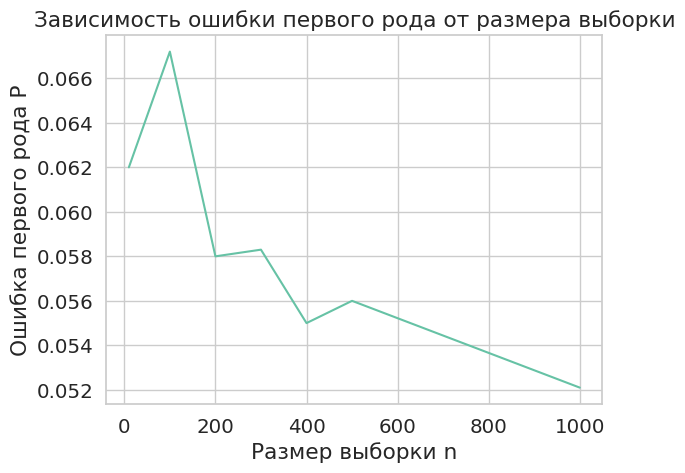

In [114]:
plt.plot(n_range, ests)
plt.title('Зависимость ошибки первого рода от размера выборки')
plt.xlabel('Размер выборки n')
plt.ylabel('Ошибка первого рода P')
plt.show()

**Вывод:**

С ростом размер выборки результаты получается всё более надёжные: ошибка первого рода падает. Сравнительно стабилный результат получается при значениях n~1000

---
© 2025 команда <a href="https://thetahat.ru/">ThetaHat</a> для DS-потока